We we'll try to modelize the market making simulation of Avellaneda-Stoikov model

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [126]:
# Comportement du prix : mouvement brownien arithmétique (Avellaneda-Stoikov),
# et non géométrique

def simulate_bm(T, n, n_paths,s,sigma):
    dt = T / n  # pas de temps : [0,T] découpé en n intervalles

    dW = sigma * np.sqrt(dt) * np.random.randn(n_paths, n)  # accroissements indépendants ~ N(0, sigma^2 * dt)

    W = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(dW, axis=1)], axis=1)  # cumsum reconstruit la trajectoire : W_tk = somme des dW_j (télescopage)

    W= W + s #départ de l'actif en s
    return W

In [141]:
def simulate_bm_plot(T, n, n_paths,s,sigma):
    W=simulate_bm(T, n, n_paths,s,sigma)

    t = np.linspace(0, T, n + 1) #barre de temps
    for k in range(0,n_paths):
        plt.plot(t,W[k])
    plt.xlabel('t')
    plt.ylabel('Wt')
    plt.title('Brownian Motion')
    plt.show()


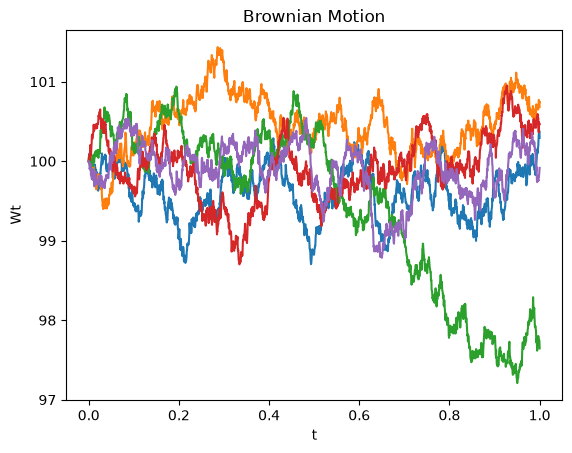

In [146]:
simulate_bm_plot(1, 2000, n_paths=5,s=100,sigma=2)

In [181]:
T=1
sigma=2
dt=0.005
q=0
gamma=0.1
k=1.5
A=140

In [ ]:
#Let's try to calculate the benchmark strategy ? 

def simule_PNL_benchmark(T,dt,sigma,q,gamma,k,A,s):
    n=int(T/dt)
    t=np.linspace(0,T,n+1)
    spread=gamma*(sigma**2)*(T-t)+(2/gamma)*np.log(1+(gamma/k))

    mid_price=simulate_bm(T, n, 1,s,sigma)[0]
    
    lower=mid_price-spread/2
    upper=mid_price+spread/2
    
    return mid_price,spread

    

In [123]:
def simule_PNL_benchmark_plot(T,dt,sigma,q,gamma,k,A,s):
    n=int(T/dt)
    t=np.linspace(0,T,n+1)
    mid_price,spread=simule_PNL_benchmark(T,dt,sigma,q,gamma,k,A,s)

    lower=mid_price-spread/2
    upper=mid_price+spread/2

    plt.plot(t,mid_price)
    plt.fill_between(t,lower,upper,color='orange',alpha=0.2,label="spread")
    plt.xlabel("t")
    plt.title("Mid_price evolution with spread")

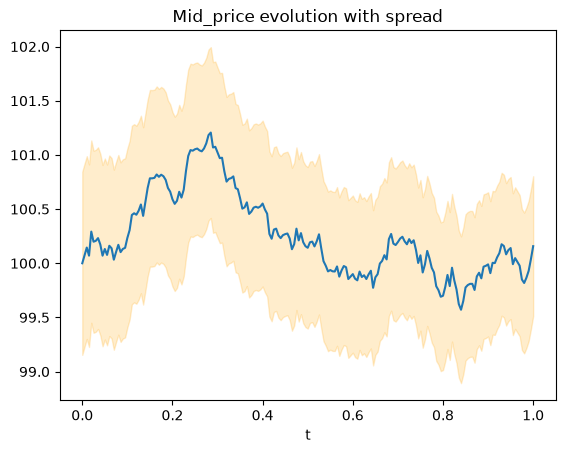

In [125]:
simule_PNL_benchmark_plot(T,dt,sigma,q,gamma,k,A,s)

In [ ]:
#Now let's simulate it's strategy 

def simule_PNL_AS(T,dt,sigma,q,gamma,k,A,s):
    
    n=int(T/dt)
    t=np.linspace(0,T,n+1)

    w=0 #initialisation de la wealth
    
    
    wealth=[0]*(n+1) #tableau de suivi de la wealth
    p_a=[0]*(n+1) #tableau de suivi des prix ask
    p_b=[0]*(n+1) #tableau de suivi des prix bid
    res_price_evo=[0]*(n+1) #tableau de suivi du prix de réservation

    spread=gamma*(sigma**2)*(T-t)+(2/gamma)*np.log(1+(gamma/k)) # δa + δb 

    mid_price=simulate_bm(T, n, 1,s,sigma)[0]


    for i in range(n+1):

        reserve_price=mid_price[i]-q*gamma*(sigma**2)*(T-t[i]) #valorisation de l'actif selon l'agent à la période k

        delta_a= (spread[i]/2) - q*gamma*(sigma**2)*(T-t[i]) # -q*gamma*(sigma**2)*(T-t) = reserve_price - mid_price
        delta_b= (spread[i]/2) + q*gamma*(sigma**2)*(T-t[i]) # +q*gamma*(sigma**2)*(T-t) = mid_price - reserve_price

        lambda_a_delta_a=A*np.exp(-k*delta_a) # λ(δa) : our arrival rate is a function of δa (completely normal considering that price affect sales)
        lambda_b_delta_b=A*np.exp(-k*delta_b) # λ(δb) 

        a=np.random.binomial(1,1-np.exp(-lambda_a_delta_a*dt),1) #we use 1-exp(-λ(δa)) rather than λ(δa) (which could be >1)
        b=np.random.binomial(1,1-np.exp(-lambda_b_delta_b*dt),1)

        q= q+a-b # increase by 1 with probability λ(δa)*dt and decrease by 1 with probability λ(δb)*dt

        w = w + (s+delta_a)*a - (s-delta_b)*b
        
        #=== To follow the evolutions
        wealth[i]=w

        p_a[i]=mid_price[i]+delta_a
        p_b[i]=mid_price[i]-delta_b

        res_price_evo[i]=reserve_price

        wealth=np.darray(wealth)
    

    
    return wealth,p_a,p_b,mid_price,res_price_evo


In [ ]:
simule_PNL_AS(T,dt,sigma,q,gamma,k,A,s)[0].shape(

AttributeError: 'list' object has no attribute 'shape'

In [153]:
def simule_PNL_AS_plot(T,dt,sigma,q,gamma,k,A,s):
    n=int(T/dt)
    t=np.linspace(0,T,n+1)
    wealth,p_a,p_b,mid_price,res_price_evo = simule_PNL_AS(T,dt,sigma,q,gamma,k,A,s)

    plt.plot(t,mid_price,color='black',label='Mid-market price')
    plt.plot(t,res_price_evo,color='green',label='Indifference price')
    plt.scatter(t,p_a,facecolors='red', label='Price asked')
    plt.scatter(t,p_b,facecolors='none',edgecolors='red',s=50, label='Price bid')
    plt.xlabel("t")
    plt.legend()
    plt.show()

    plt.plot(t,wealth,color='orange',label=wealth)
    plt.xlabel("t")
    plt.title("Wealth evolution")
    plt.legend()
    plt.show()

In [154]:
simule_PNL_AS_plot(T,dt,sigma,q,gamma,k,A,s)

ValueError: Output size (1,) is not compatible with broadcast dimensions of inputs (201,).